# Event Poster Critic: training notebook

**Goal:** learn **image → human rating** for three design principles (alignment, overlap, white space), then serve it as a critique tool.

**Setup:** in Colab, go to **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**.

### Requirements
- **Steps 1–8 need no account or token.** The dataset and models are public.
- **Step 9 (deploy) needs a Hugging Face Write token:** huggingface.co → Settings → Access Tokens → Create new token → type **Write**.
  - Either save it as a Colab secret named `HF_TOKEN` (🔑 in the left sidebar, with notebook access turned on), or paste it when step 9 asks.
  - Step 9 creates the Space under **your own** HF account (`<your-username>/<HF_SPACE_NAME>`), so it can't overwrite anyone else's Space.

| Step | What happens |
|---|---|
| 1 | Install packages and check for a GPU |
| 2 | Load the GraphicDesignEvaluation dataset (human ratings from 60 raters) |
| 3 | Convert images to vectors with 3 frozen image models (CLIP-B/32, CLIP-L/14, SigLIP) |
| 4 | Compare ridge vs MLP regressors with grouped cross-validation, and produce a **results table for the slides** |
| 5 | Train the final model and save `model.joblib` |
| 6 | Test it on your own campus posters (optional) |
| 7 | Launch a Gradio demo inside Colab (temporary public link) |
| 8 | Download `model.joblib` (for the Gradio version in `app/`) |
| 9 | Export `weights.json` and deploy to a free HF Static Space (**needs a token**) |

## 1. Setup

In [13]:
!pip -q install -U datasets gradio scikit-learn joblib
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

Device: cuda Tesla T4


In [14]:
# Set QUICK = True for a fast smoke test (small subset, 2 backbones). Set it to False for the real run.
QUICK = False

# Step 9 deploys to https://huggingface.co/spaces/<your-username>/<HF_SPACE_NAME> (always under your own account)
HF_SPACE_NAME = "event-poster-critic"

## 2. Data
[GraphicDesignEvaluation](https://huggingface.co/datasets/creative-graphic-design/GraphicDesignEvaluation): each design appears as the original plus 3 damaged versions (`perturbation` = none / small / medium / large). Each image has 5 human ratings on a 1–10 scale; `avg` is our target.

In [15]:
import numpy as np, pandas as pd
from datasets import load_dataset

PRINCIPLES = ["alignment", "overlap", "whitespace"]
data = {}
for p in PRINCIPLES:
    ds = load_dataset("creative-graphic-design/GraphicDesignEvaluation", f"absolute-human-{p}", split="train")
    if QUICK:
        ds = ds.select(range(80))
    data[p] = ds
    print(f"{p:11s} {len(ds)} images, {len(set(ds['image_id']))} designs, "
          f"mean rating {np.mean(ds['avg']):.2f} ± {np.std(ds['avg']):.2f}")

alignment   400 images, 100 designs, mean rating 5.57 ± 2.30
overlap     400 images, 100 designs, mean rating 5.54 ± 1.95
whitespace  400 images, 100 designs, mean rating 5.54 ± 1.82


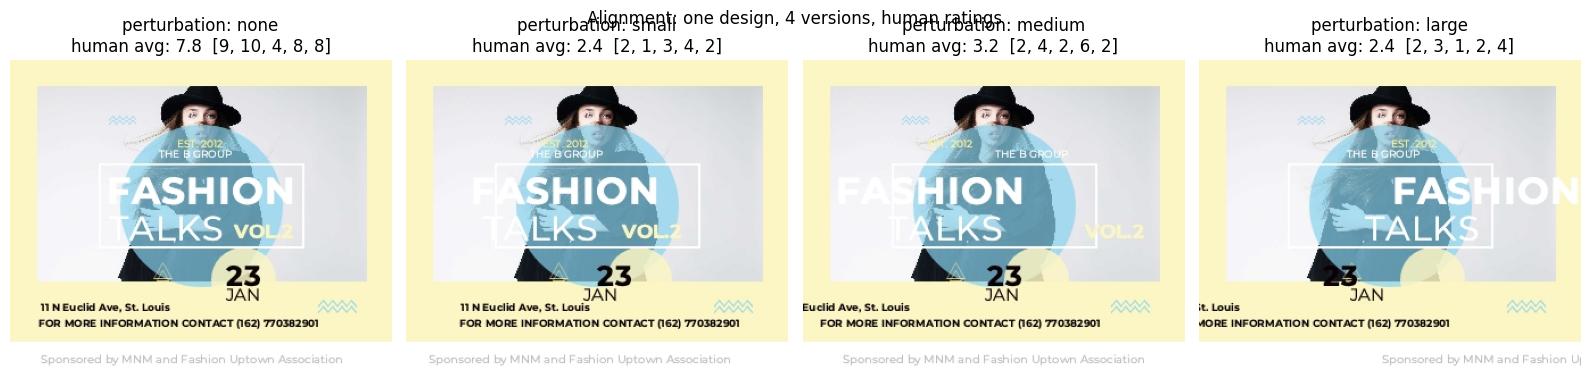

In [16]:
# Slide visual: one design next to its damaged versions, with human scores
import matplotlib.pyplot as plt
ds = data["alignment"]
first_id = ds[0]["image_id"]
rows = [r for r in ds.select(range(12)) if r["image_id"] == first_id]
names = ["none", "small", "medium", "large"]
fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 4))
for ax, r in zip(np.atleast_1d(axes), rows):
    ax.imshow(r["image"]); ax.axis("off")
    ax.set_title(f"perturbation: {names[r['perturbation']]}\nhuman avg: {r['avg']:.1f}  {r['scores']}")
plt.suptitle("Alignment: one design, 4 versions, human ratings"); plt.tight_layout(); plt.show()

In [17]:
# How much do the 5 human raters agree with each other? (sets a ceiling on model accuracy)
from scipy.stats import spearmanr
for p, ds in data.items():
    S = [s for s in ds["scores"] if len(s) >= 2]  # the number of raters varies per image
    rho = spearmanr([s[0] for s in S], [np.mean(s[1:]) for s in S]).correlation
    print(f"{p:11s} one rater vs. the other raters: Spearman {rho:.2f}")

alignment   one rater vs. the other raters: Spearman 0.82
overlap     one rater vs. the other raters: Spearman 0.70
whitespace  one rater vs. the other raters: Spearman 0.56


## 3. Frozen image features
The pretrained models only **describe** each image as a vector. The quality judgment is learned in step 4.

In [18]:
from transformers import AutoModel, AutoImageProcessor

BACKBONES = {
    "CLIP-B/32": "openai/clip-vit-base-patch32",
    "CLIP-L/14": "openai/clip-vit-large-patch14",
    "SigLIP-B/16": "google/siglip-base-patch16-224",
}
if QUICK:
    BACKBONES = {k: BACKBONES[k] for k in ["CLIP-B/32", "SigLIP-B/16"]}

def load_backbone(model_id):
    model = AutoModel.from_pretrained(model_id).to(DEVICE).eval()
    proc = AutoImageProcessor.from_pretrained(model_id)
    return model, proc

@torch.no_grad()
def embed(images, model, proc, batch_size=64):
    out = []
    for i in range(0, len(images), batch_size):
        batch = [im.convert("RGB") for im in images[i:i + batch_size]]
        inputs = proc(images=batch, return_tensors="pt").to(DEVICE)
        f = model.get_image_features(**inputs)
        f = f if torch.is_tensor(f) else f.pooler_output  # transformers >= 5 returns an output object
        out.append(torch.nn.functional.normalize(f.float(), dim=-1).cpu().numpy())
    return np.concatenate(out)

features = {}  # (backbone, principle) -> X
for name, mid in BACKBONES.items():
    model, proc = load_backbone(mid)
    for p, ds in data.items():
        features[(name, p)] = embed(ds["image"], model, proc)
    print(f"{name}: dim {features[(name, p)].shape[1]}")
    del model; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP-B/32: dim 512


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIP-L/14: dim 768


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  813MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

SigLIP-B/16: dim 768


## 4. Learn the relationship: compare models
- **Grouped 5-fold CV:** all 4 versions of a design stay in the same fold, so the model is never tested on a design it saw during training.
- **Metrics:** MAE (average error in rating points; lower is better) and Spearman correlation (does it rank posters the way humans do? higher is better).
- **Baseline:** always predict the average rating.

In [19]:
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_predict

HEADS = {
    "Ridge": lambda: RidgeCV(alphas=np.logspace(-2, 3, 12)),
    "MLP": lambda: make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=(256,), alpha=1e-1, early_stopping=True, max_iter=500, random_state=0)),
}

results, preds = [], {}
for p, ds in data.items():
    y = np.array(ds["avg"]); groups = np.array(ds["image_id"])
    cv = GroupKFold(n_splits=5)
    base = np.abs(y - y.mean()).mean()
    results.append(dict(principle=p, backbone="—", head="Baseline (predict mean)", MAE=base, Spearman=0.0))
    for b in BACKBONES:
        X = features[(b, p)]
        for h, make in HEADS.items():
            pr = np.clip(cross_val_predict(make(), X, y, cv=cv, groups=groups), 1, 10)
            preds[(b, h, p)] = pr
            results.append(dict(principle=p, backbone=b, head=h,
                                MAE=np.abs(pr - y).mean(), Spearman=spearmanr(pr, y).correlation))

res = pd.DataFrame(results)
res.round(3)

,principle,backbone,head,MAE,Spearman
0,alignment,—,Baseline (predict mean),1.950,0.000
1,alignment,CLIP-B/32,Ridge,1.780,0.392
2,alignment,CLIP-B/32,MLP,2.682,0.288
3,alignment,CLIP-L/14,Ridge,2.129,0.204
4,alignment,CLIP-L/14,MLP,2.727,0.214
5,alignment,SigLIP-B/16,Ridge,2.061,0.338
6,alignment,SigLIP-B/16,MLP,2.718,0.340
7,overlap,—,Baseline (predict mean),1.699,0.000
8,overlap,CLIP-B/32,Ridge,1.614,0.401
9,overlap,CLIP-B/32,MLP,2.388,0.347


In [20]:
# Slide table: mean across principles, per backbone + head
summary = (res[res.backbone != "—"].groupby(["backbone", "head"])[["MAE", "Spearman"]]
           .mean().sort_values("Spearman", ascending=False))
print("Baseline MAE (mean over principles):", round(res[res.backbone == "—"].MAE.mean(), 3))
summary.round(3)

Baseline MAE (mean over principles): 1.732


MAE  Spearman
backbone    head                  
SigLIP-B/16 Ridge  1.593     0.464
            MLP    2.488     0.407
CLIP-B/32   Ridge  1.646     0.378
            MLP    2.464     0.310
CLIP-L/14   MLP    2.577     0.287
            Ridge  1.802     0.277

Backbone: SigLIP-B/16 | heads: {'alignment': 'MLP', 'overlap': 'Ridge', 'whitespace': 'Ridge'}


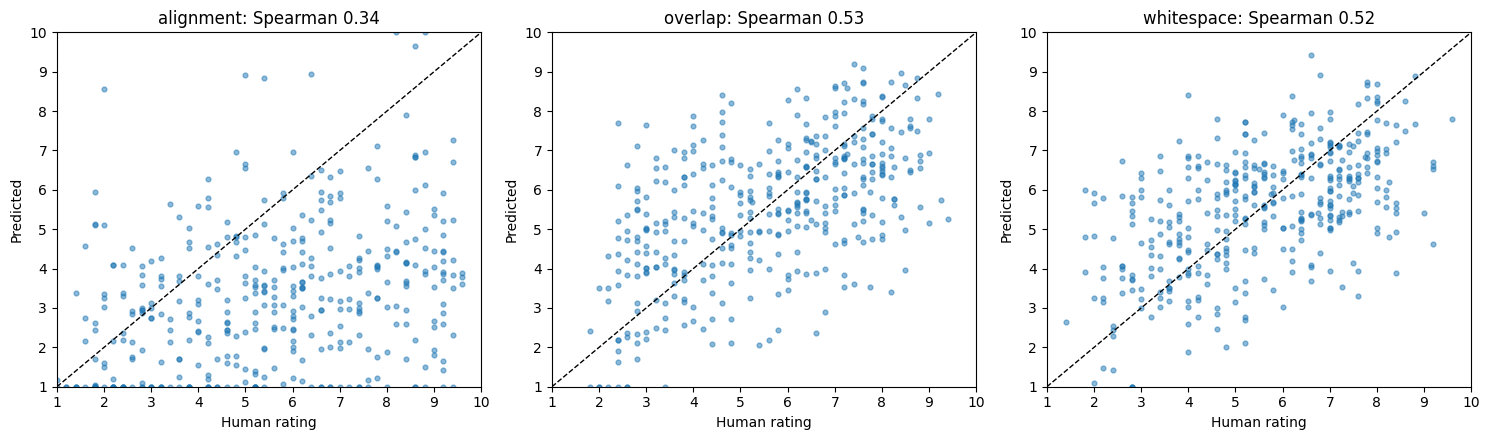

In [21]:
# Pick one backbone for the app (best mean Spearman), then the best head per principle
BEST_BACKBONE = summary.reset_index().groupby("backbone").Spearman.max().idxmax()
best_heads = {}
for p in PRINCIPLES:
    r = res[(res.principle == p) & (res.backbone == BEST_BACKBONE)].sort_values("Spearman", ascending=False).iloc[0]
    best_heads[p] = r["head"]
print("Backbone:", BEST_BACKBONE, "| heads:", best_heads)

# Slide visual: predicted vs. human rating on held-out designs
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, p in zip(axes, PRINCIPLES):
    y = np.array(data[p]["avg"]); pr = preds[(BEST_BACKBONE, best_heads[p], p)]
    ax.scatter(y, pr, s=12, alpha=0.5); ax.plot([1, 10], [1, 10], "k--", lw=1)
    ax.set(xlim=(1, 10), ylim=(1, 10), xlabel="Human rating", ylabel="Predicted",
           title=f"{p}: Spearman {spearmanr(pr, y).correlation:.2f}")
plt.tight_layout(); plt.show()

## 5. Train the final model on all the data and save it

In [22]:
import os, joblib
final = {"backbone_id": BACKBONES[BEST_BACKBONE], "backbone": BEST_BACKBONE, "models": {}}
for p in PRINCIPLES:
    m = HEADS[best_heads[p]]()
    m.fit(features[(BEST_BACKBONE, p)], np.array(data[p]["avg"]))
    final["models"][p] = m
joblib.dump(final, "model.joblib")
print("Saved model.joblib")

Saved model.joblib


## 6. Test on your own event posters
Upload photos or screenshots of real campus posters. This checks whether a model trained on web graphics carries over to printed posters. Keep a note of what it gets right and wrong for the limitations slide.

In [23]:
from PIL import Image
backbone, processor = load_backbone(final["backbone_id"])

TIPS = {
    "alignment": "Elements don't line up. Snap text and images to a shared grid or left edge.",
    "overlap": "Elements collide. Keep text off busy image areas and separate overlapping blocks.",
    "whitespace": "Spacing feels off. Add margins and breathing room, or cut content so it isn't crammed.",
}
THRESHOLD = 6.0

def score(img):
    x = embed([img], backbone, processor)
    return {p: float(np.clip(m.predict(x)[0], 1, 10)) for p, m in final["models"].items()}

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

In [24]:
TEST_OWN_POSTERS = False  # set to True and re-run this cell to upload your own posters
uploaded = {}
if TEST_OWN_POSTERS:
    from google.colab import files
    uploaded = files.upload()
for fname in uploaded:
    img = Image.open(fname)
    s = score(img)
    plt.figure(figsize=(4, 5)); plt.imshow(img); plt.axis("off")
    plt.title("  ".join(f"{p[:5]} {v:.1f}" for p, v in s.items())); plt.show()

## 7. Gradio demo inside Colab (`share=True` gives a temporary public link)

In [25]:
import gradio as gr

def critique(img):
    if img is None:
        return {}, "Upload a poster to get feedback."
    s = score(img)
    weak = sorted((v, p) for p, v in s.items() if v < THRESHOLD)
    fb = "\n".join(f"- **{p.title()}** ({v:.1f}/10): {TIPS[p]}" for v, p in weak) \
         or "Looks solid on alignment, overlap and white space. Nice work!"
    return {p.title(): v / 10 for p, v in s.items()}, fb

demo = gr.Interface(
    fn=critique,
    inputs=gr.Image(type="pil", label="Your event poster"),
    outputs=[gr.Label(label="Predicted human rating (/10)"), gr.Markdown()],
    title="Event Poster Critic",
    description="Scores alignment, overlap and white space using a model trained on ratings from 60 human judges.",
    flagging_mode="never",
)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://872d97864009dc5880.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Download the model for the Hugging Face Space
This downloads `model.joblib`. Put it in the `app/` folder next to `app.py`, then upload `app.py`, `requirements.txt`, `README.md` and `model.joblib` to a new **Gradio** Space (the free CPU tier is fine).

**Important:** replace the `scikit-learn` line in `app/requirements.txt` with the pinned version printed below. The model file only loads reliably with the same scikit-learn version that saved it.

In [26]:
import sklearn
print("Put this line in app/requirements.txt:  scikit-learn==" + sklearn.__version__)
try:
    from google.colab import files; files.download("model.joblib")
except ImportError:
    print("Not in Colab: model.joblib is in", os.getcwd())

Put this line in app/requirements.txt:  scikit-learn==1.9.1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Deploy to the free Static Space
Gradio Spaces need HF PRO, so the live demo is a Static Space that runs the model in the browser (see `space/`).
This cell exports the trained regressors to `weights.json` and uploads it to the Space.

In [ ]:
import os, json, joblib, numpy as np
from getpass import getpass
from huggingface_hub import login, whoami, create_repo, upload_file

# Token: a Colab secret named HF_TOKEN if you have one, otherwise a prompt (never hardcode it here)
try:
    from google.colab import userdata
    token = userdata.get("HF_TOKEN")
except Exception:
    token = None
login(token=token or getpass("HF write token: "))

SPACE = f"{whoami()['name']}/{HF_SPACE_NAME}"  # your own account, so you can't overwrite a teammate's Space
create_repo(SPACE, repo_type="space", space_sdk="static", exist_ok=True)  # Static Spaces are free

final = joblib.load("model.joblib")
r = lambda a: np.round(np.asarray(a, dtype=float), 6).tolist()
out = {"backbone_id": final["backbone_id"], "backbone": final["backbone"], "threshold": 6.0, "models": {}}
for p, m in final["models"].items():
    if hasattr(m, "steps"):  # StandardScaler + MLP
        sc, mlp = m.steps[0][1], m.steps[-1][1]
        out["models"][p] = {"type": "mlp", "mean": r(sc.mean_), "scale": r(sc.scale_),
                            "layers": [{"W": r(W), "b": r(b)} for W, b in zip(mlp.coefs_, mlp.intercepts_)]}
    else:  # Ridge
        out["models"][p] = {"type": "linear", "coef": r(m.coef_), "intercept": float(m.intercept_)}
json.dump(out, open("weights.json", "w"))
upload_file(path_or_fileobj="weights.json", path_in_repo="weights.json", repo_id=SPACE, repo_type="space")

# If the repo's space/ folder is available (e.g. you cloned the repo), upload the page too
for f in ["index.html", "critic.js", "README.md"]:
    if os.path.exists(f"space/{f}"):
        upload_file(path_or_fileobj=f"space/{f}", path_in_repo=f, repo_id=SPACE, repo_type="space")
    else:
        print(f"space/{f} not found here: upload it to the Space by hand (Files → Add file → Upload files)")

print("Deployed backbone:", final["backbone"], "→ https://huggingface.co/spaces/" + SPACE)